# Import library pandas

In [1]:
import pandas as pd 

# Load Data

In [2]:
df = pd.read_csv("data/sales_data (1).csv")

# Data Exploring 

In [3]:
df.head(10)

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
5,2024-01-06,Laptop,7,40420,CUST006,South,282940
6,2024-01-07,Laptop,9,40430,CUST007,South,363870
7,2024-01-08,Laptop,7,7262,CUST008,West,50834
8,2024-01-09,Tablet,3,32791,CUST009,North,98373
9,2024-01-10,Laptop,4,45023,CUST010,West,180092


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [5]:
df.shape


(100, 7)

In [6]:
df.columns

Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

In [7]:
df.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


# Data cleaning

In [8]:
df.isnull()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False
98,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()


Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

In [10]:
df.dropna()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,CUST096,North,166160
96,2024-04-06,Headphones,1,7647,CUST097,West,7647
97,2024-04-07,Tablet,5,27196,CUST098,East,135980
98,2024-04-08,Monitor,1,30717,CUST099,North,30717


In [11]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [12]:
df.drop_duplicates()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,CUST096,North,166160
96,2024-04-06,Headphones,1,7647,CUST097,West,7647
97,2024-04-07,Tablet,5,27196,CUST098,East,135980
98,2024-04-08,Monitor,1,30717,CUST099,North,30717


# visulation (graphs and chart)

In [13]:
product_sales = df.groupby("Product")["Total_Sales"].sum()
product_sales

Product
Headphones    1384033
Laptop        3889210
Monitor       1348071
Phone         2859394
Tablet        2884340
Name: Total_Sales, dtype: int64

In [14]:
import matplotlib.pyplot as plt

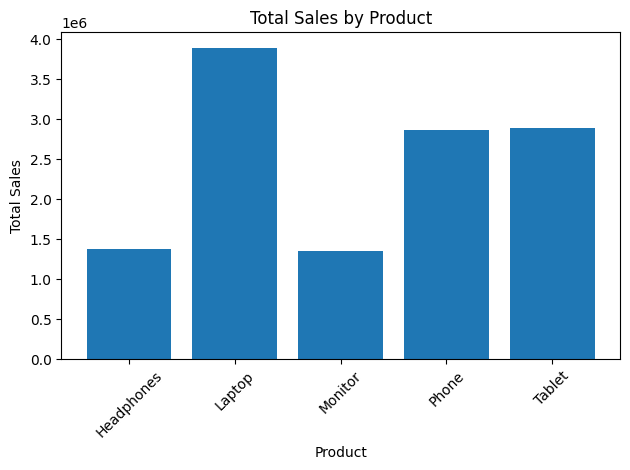

In [15]:
plt.bar(product_sales.index, product_sales.values)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visualizations/sales_by_product.png")
plt.show()

In [16]:
daily_sales = df.groupby("Date")["Total_Sales"].sum()
daily_sales

Date
2024-01-01    261100
2024-01-02     61624
2024-01-03     43492
2024-01-04     30895
2024-01-05    318680
               ...  
2024-04-05    166160
2024-04-06      7647
2024-04-07    135980
2024-04-08     30717
2024-04-09    116880
Name: Total_Sales, Length: 100, dtype: int64

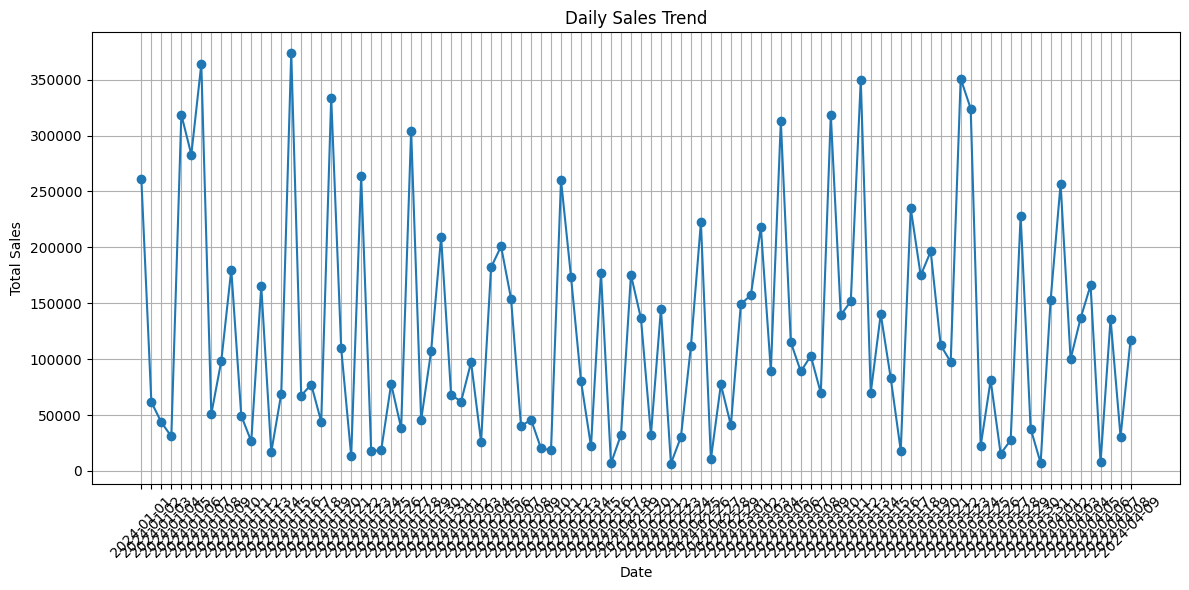

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.values, marker="o")

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("visualizations/daily_sales_trend.png")
plt.show()

In [18]:
df.columns

Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

In [19]:
best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

print("Best-Selling Product:", best_product)
print("Sales:", best_product_sales)

Best-Selling Product: Laptop
Sales: 3889210


In [20]:
lowest_product = product_sales.idxmin()
lowest_product_sales = product_sales.min()

print("Lowest-Selling Product:", lowest_product)
print("Sales:", lowest_product_sales)

Lowest-Selling Product: Monitor
Sales: 1348071


In [21]:
highest_day = df.loc[df["Total_Sales"].idxmax(), "Date"]
highest_day_sales = df["Total_Sales"].max()

print("Highest Sales Date:", highest_day)
print("Highest Single-Day Sale:", highest_day_sales)

Highest Sales Date: 2024-01-16
Highest Single-Day Sale: 373932


In [22]:
total_sales = df["Total_Sales"].sum()
average_sales = df["Total_Sales"].mean()

print("Total Sales:", total_sales)
print("Average Sale:", average_sales)

Total Sales: 12365048
Average Sale: 123650.48


In [23]:
highest_day = df.loc[df["Total_Sales"].idxmax(), "Date"]
highest_day_sales = df["Total_Sales"].max()

print("Highest Sales Date:", highest_day)
print("Highest Single Sale:", highest_day_sales)

Highest Sales Date: 2024-01-16
Highest Single Sale: 373932


# Key Insights

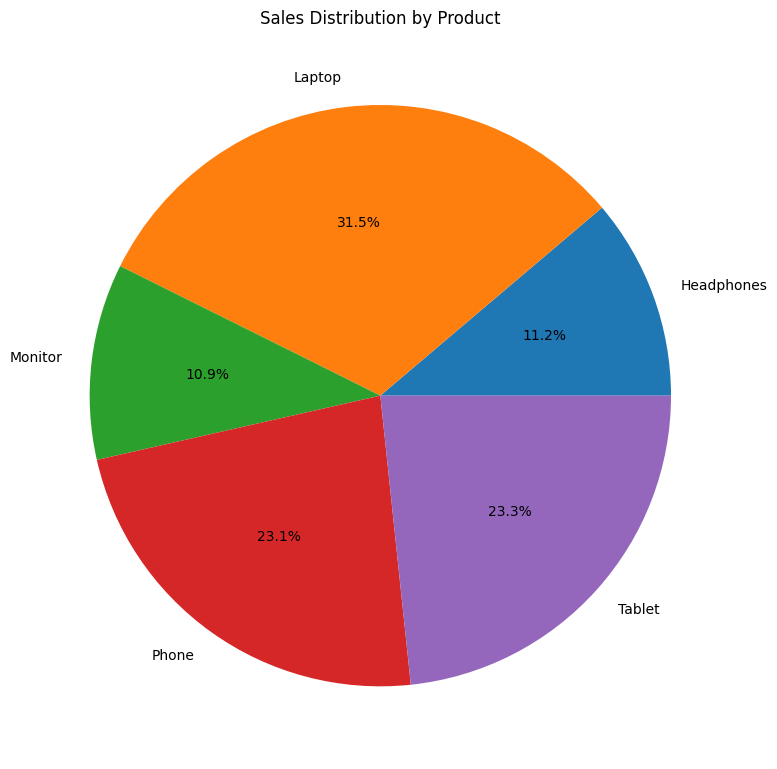

In [24]:
plt.figure(figsize=(8, 8))

plt.pie(
    product_sales.values,
    labels=product_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Product")

plt.tight_layout()
plt.savefig("visualizations/sales_distribution.png")
plt.show()

In [25]:
import os

file_path = "sales_data (1).csv"

if not os.path.exists(file_path):
    print("Error: CSV file not found.")
else:
    print("CSV file found successfully.")

Error: CSV file not found.


In [26]:
required_columns = [
    "Date",
    "Product",
    "Quantity",
    "Price",
    "Customer_ID",
    "Region",
    "Total_Sales"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Error: Missing columns:", missing_columns)
else:
    print("All required columns are present.")

All required columns are present.


In [27]:
print(df.dtypes)

Date           object
Product        object
Quantity        int64
Price           int64
Customer_ID    object
Region         object
Total_Sales     int64
dtype: object


In [28]:
numeric_columns = ["Quantity", "Price", "Total_Sales"]

for col in numeric_columns:
    if (df[col] < 0).any():
        print(f"Error: Negative values found in {col}")
    else:
        print(f"{col}: Valid")

Quantity: Valid
Price: Valid
Total_Sales: Valid


In [29]:
date_check = pd.to_datetime(df["Date"], errors="coerce")

if date_check.isna().any():
    print("Error: Invalid date values found.")
else:
    print("All date values are valid.")

All date values are valid.


# Key Insights

# Project Summary